In [1]:
import pandas as pd  # biblioteka do pracy z danymi tabelarycznymi

# wczytanie danych treningowych
X_train = pd.read_csv(
    "samsung_train.txt",  
    sep=r"\s+",           # separator = dowolna liczba spacji
    header=None           
)

# wczytanie etykiet treningowych
y_train = pd.read_csv(
    "samsung_train_labels.txt",  
    header=None                
)

# wczytanie danych testowych
X_test = pd.read_csv(
    "samsung_test.txt",  
    sep=r"\s+",          # separator = dowolna liczba spacji
    header=None          
)

# wczytanie etykiet testowych
y_test = pd.read_csv(
    "samsung_test_labels.txt",  
    header=None                 
)


print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (7352, 561)
X_test: (2947, 561)
y_train: (7352, 1)
y_test: (2947, 1)


desc:
W tym kroku wczytujemy dane treningowe, dane testowe oraz odpowiadające im etykiety. Pliki zawierają 561 cech opisujących aktywność użytkownika telefonu. Na końcu sprawdzamy rozmiary wszystkich zbiorów, aby upewnić się, że dane zostały poprawnie załadowane.

In [2]:
# połączenie danych treningowych i testowych w jeden zbiór
X = pd.concat(
    [X_train, X_test],  # lista łączonych zbiorów
    ignore_index=True   # utworzenie nowej numeracji wierszy
)

# połączenie etykiet treningowych i testowych
y = pd.concat(
    [y_train, y_test],  # lista łączonych etykiet
    ignore_index=True   # utworzenie nowej numeracji wierszy
)

# wyświetlenie rozmiaru połączonego zbioru cech
print("X:", X.shape)

# wyświetlenie rozmiaru połączonych etykiet
print("y:", y.shape)

X: (10299, 561)
y: (10299, 1)


desc:
Ponieważ wykonujemy klasteryzację (Unsupervised Learning), nie musimy korzystać z podziału train/test. Łączymy oba zbiory w jeden większy zbiór danych. Etykiety zachowujemy wyłącznie do późniejszej oceny jakości klasteryzacji.

#skalowanie

In [3]:
from sklearn.preprocessing import StandardScaler  # import skalera

# utworzenie obiektu skalera
scaler = StandardScaler()

# skalowanie wszystkich cech
X_scaled = scaler.fit_transform(X)

# wyświetlenie rozmiaru przeskalowanych danych
print(X_scaled.shape)

(10299, 561)


desc:Algorytmy K-Means, DBSCAN i GMM wykorzystują odległości pomiędzy obserwacjami. Dlatego przed klasteryzacją standaryzujemy dane tak, aby każda cecha miała średnią równą 0 i odchylenie standardowe równe 1.


# Elbow Method

In [4]:
from sklearn.cluster import KMeans  # import algorytmu K-Means

# lista do przechowywania wartości inertia
inertias = []

# sprawdzamy różne liczby klastrów
for k in range(2, 15):

    # utworzenie modelu K-Means
    model = KMeans(
        n_clusters=k,   # liczba klastrów
        random_state=42 # ustalenie ziarna losowości
    )

    # trening modelu
    model.fit(X_scaled)

    # zapisanie wartości inertia
    inertias.append(
        model.inertia_
    )

Dla różnych wartości k obliczamy wartość inertia (SSE). Im mniejsza wartość, tym lepiej dane pasują do klastrów. Szukamy punktu przegięcia na wykresie, który sugeruje optymalną liczbę klastrów.

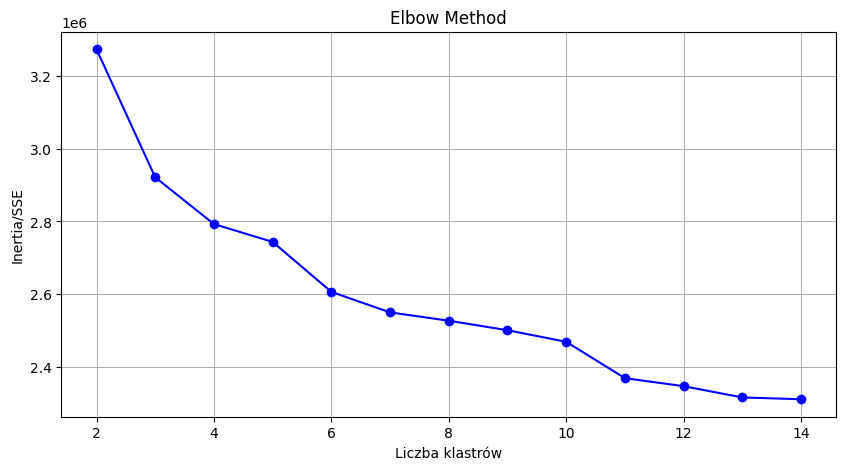

In [5]:
import matplotlib.pyplot as plt  # biblioteka do tworzenia wykresów

# utworzenie figury
plt.figure(figsize=(10, 5))

# narysowanie wykresu
plt.plot(
    range(2, 15),  # liczba klastrów
    inertias,      # wartości inertia
    "bo-"          # niebieskie punkty połączone linią
)

# opis osi X
plt.xlabel("Liczba klastrów")

# opis osi Y
plt.ylabel("Inertia/SSE")

# tytuł wykresu
plt.title("Elbow Method")

# włączenie siatki
plt.grid()

# wyświetlenie wykresu
plt.show()

# Silhouette Score

In [6]:
from sklearn.metrics import silhouette_score  # import metryki silhouette score

# lista do przechowywania wyników
scores = []

# sprawdzamy różne liczby klastrów
for k in range(2, 15):

    # utworzenie modelu K-Means
    model = KMeans(
        n_clusters=k,   # liczba klastrów
        random_state=42 # ustalenie ziarna losowości
    )

    # trening modelu i przypisanie punktów do klastrów
    labels = model.fit_predict(
        X_scaled
    )

    # obliczenie silhouette score
    score = silhouette_score(
        X_scaled,  # dane wejściowe
        labels     # przypisane klastry
    )

    # zapisanie wyniku
    scores.append(score)

desc: Silhouette Score mierzy jednocześnie spójność klastrów i ich separację. Im wyższy wynik, tym lepszy podział danych na klastry.

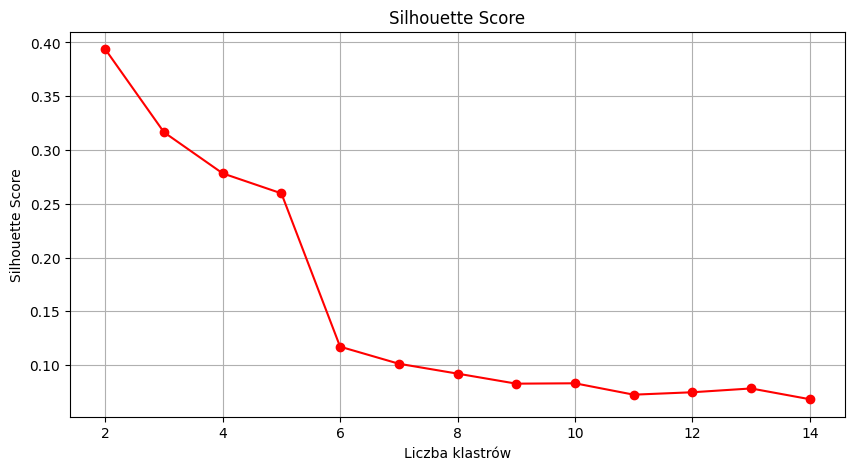

In [7]:
# utworzenie figury
plt.figure(figsize=(10, 5))

# narysowanie wykresu
plt.plot(
    range(2, 15),  # liczba klastrów
    scores,        # silhouette score
    "ro-"          # czerwone punkty połączone linią
)

# opis osi X
plt.xlabel("Liczba klastrów")

# opis osi Y
plt.ylabel("Silhouette Score")

# tytuł wykresu
plt.title("Silhouette Score")

# włączenie siatki
plt.grid()

# wyświetlenie wykresu
plt.show()

In [8]:
for k, score in zip(range(2, 15), scores):
    print(f"k = {k}, score = {score:.4f}")

k = 2, score = 0.3937
k = 3, score = 0.3165
k = 4, score = 0.2783
k = 5, score = 0.2597
k = 6, score = 0.1171
k = 7, score = 0.1012
k = 8, score = 0.0920
k = 9, score = 0.0827
k = 10, score = 0.0830
k = 11, score = 0.0724
k = 12, score = 0.0747
k = 13, score = 0.0782
k = 14, score = 0.0682


# Model K_Means

In [9]:
# utworzenie końcowego modelu K-Means
kmeans = KMeans(
    n_clusters=6,   # liczba aktywności w zbiorze
    random_state=42 # ustalenie ziarna losowości
)

# trening modelu
kmeans.fit(
    X_scaled
)

# zapisanie przypisanych klastrów
clusters_kmeans = kmeans.labels_

desc: Tworzymy finalny model K-Means wykorzystujący 6 klastrów odpowiadających sześciu aktywnościom człowieka.

#ocena K-means za pomoca ARI 

In [10]:
from sklearn.metrics import adjusted_rand_score  # import metryki ARI

# obliczenie ARI
ari_kmeans = adjusted_rand_score(
    y.iloc[:, 0],     # prawdziwe etykiety
    clusters_kmeans   # klastry K-Means
)

# wyświetlenie wyniku
print("ARI KMeans =", ari_kmeans)

ARI KMeans = 0.2850641901721631


KMeans częściowo odnalazł strukturę danych, ale klastry nie odpowiadają dobrze rzeczywistym aktywnościom.

In [11]:
from sklearn.metrics import adjusted_rand_score  # import metryki ARI

# lista na wyniki
results = []

# sprawdzamy różne liczby klastrów
for k in range(2, 15):

    # utworzenie modelu K-Means
    model = KMeans(
        n_clusters=k,   # liczba klastrów
        random_state=42 # ustalenie ziarna losowości
    )

    # trening modelu i przypisanie klastrów
    labels = model.fit_predict(
        X_scaled
    )

    # obliczenie ARI
    ari = adjusted_rand_score(
        y.iloc[:, 0],  # prawdziwe etykiety
        labels         # klastry znalezione przez K-Means
    )

    # zapisanie wyniku
    results.append(
        [k, ari]
    )

# utworzenie DataFrame z wynikami
results_df = pd.DataFrame(
    results,
    columns=[
        "k",
        "ARI"
    ]
)

# wyświetlenie tabeli
print(results_df)

     k       ARI
0    2  0.329611
1    3  0.331882
2    4  0.324653
3    5  0.321280
4    6  0.285064
5    7  0.295215
6    8  0.519368
7    9  0.529479
8   10  0.534589
9   11  0.462230
10  12  0.434400
11  13  0.443965
12  14  0.427020


Dla każdej liczby klastrów od 2 do 14 obliczamy ARI. Dzięki temu możemy sprawdzić, przy jakiej liczbie klastrów K-Means najlepiej odtwarza rzeczywiste aktywności użytkownika.

In [12]:
# sortowanie wyników od najlepszego ARI
results_df.sort_values(
    by="ARI",
    ascending=False
)

,k,ARI
8,10,0.534589
7,9,0.529479
6,8,0.519368
9,11,0.462230
11,13,0.443965
10,12,0.434400
12,14,0.427020
1,3,0.331882
0,2,0.329611
2,4,0.324653


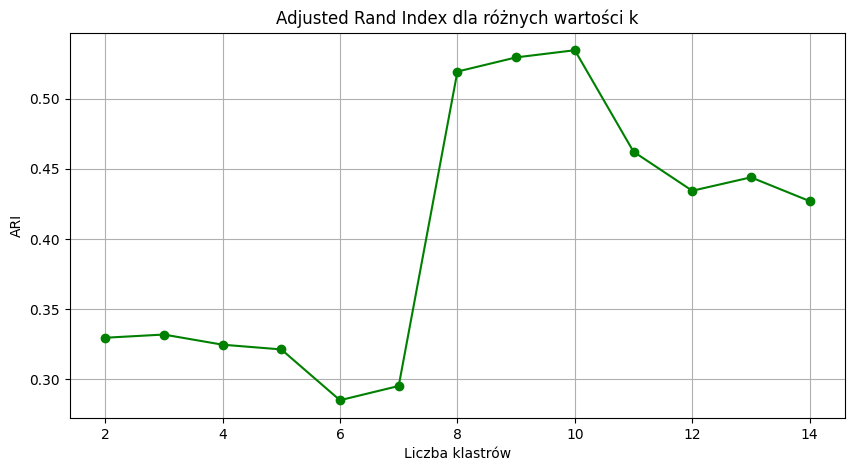

In [13]:
import matplotlib.pyplot as plt  # biblioteka do tworzenia wykresów

# utworzenie figury
plt.figure(figsize=(10, 5))

# narysowanie wykresu
plt.plot(
    results_df["k"],    # liczba klastrów
    results_df["ARI"],  # wartości ARI
    "go-"               # zielone punkty połączone linią
)

# opis osi X
plt.xlabel("Liczba klastrów")

# opis osi Y
plt.ylabel("ARI")

# tytuł wykresu
plt.title("Adjusted Rand Index dla różnych wartości k")

# włączenie siatki
plt.grid()

# wyświetlenie wykresu
plt.show()

Wykres pokazuje zależność pomiędzy liczbą klastrów a zgodnością klasteryzacji z rzeczywistymi aktywnościami. Im wyższy ARI, tym lepszy podział danych.

In [14]:
pd.crosstab(
    clusters_kmeans,
    y.iloc[:,0]
)

,1,2,3,4,5,6
row_0,,,,,,
0,0,0,0,1100,917,1360
1,726,141,868,0,0,0
2,99,10,227,0,0,0
3,810,1031,294,3,0,12
4,87,362,17,0,0,0
5,0,0,0,674,989,572


# DBSCAN

In [15]:
from sklearn.cluster import DBSCAN  # import algorytmu DBSCAN

# utworzenie modelu DBSCAN
dbscan = DBSCAN(
    eps=10,          # promień sąsiedztwa
    min_samples=10   # minimalna liczba punktów w sąsiedztwie
)

# trening modelu i przypisanie klastrów
clusters_dbscan = dbscan.fit_predict(
    X_scaled
)


DBSCAN grupuje punkty na podstawie ich gęstości. Dodatkowo potrafi oznaczać obserwacje odstające jako szum (-1).

In [16]:
import numpy as np  # biblioteka do obliczeń numerycznych

# wyświetlenie unikalnych etykiet
print(
    np.unique(clusters_dbscan)
)

[-1  0  1  2  3  4  5  6]


-1 = szum
0-6 klastry

In [17]:
# obliczenie ARI dla DBSCAN
ari_dbscan = adjusted_rand_score(
    y.iloc[:, 0],
    clusters_dbscan
)

# wyświetlenie wyniku
print("ARI DBSCAN =", ari_dbscan)

ARI DBSCAN = 0.03353453890057609


bardzo slabe ARI - klastry znalezione przez DBSCAN sa praktycznie losowe i nie odpowiadaja rzeczywistym aktywnosciom

In [18]:
pd.Series(clusters_dbscan).value_counts()

-1    8040
 0    2162
 3      31
 2      16
 1      15
 6      13
 5      12
 4      10
Name: count, dtype: int64

DBSCAN większość obserwacji nie należy do żadnego sensownego klastra

# GMM

In [19]:
from sklearn.mixture import GaussianMixture  # model mieszaniny rozkładów Gaussa
from sklearn.metrics import adjusted_rand_score  # metryka ARI

# utworzenie modelu GMM
gmm = GaussianMixture(
    n_components=6,  # liczba klastrów (6 aktywności)
    random_state=42  # ustalenie ziarna losowości
)

# trening modelu
gmm.fit(X_scaled)

# przypisanie obserwacji do klastrów
clusters_gmm = gmm.predict(X_scaled)

# obliczenie ARI
ari_gmm = adjusted_rand_score(
    y.iloc[:, 0],  # prawdziwe etykiety
    clusters_gmm   # klastry znalezione przez GMM
)

print("ARI GMM =", ari_gmm)

ARI GMM = 0.2874395263878364


desc:Model GMM zakłada, że każdy klaster pochodzi z rozkładu Gaussa. W przeciwieństwie do KMeans klastry mogą mieć różne kształty i rozmiar

In [20]:
# tabela krzyżowa klastry vs aktywności
gmm_table = pd.crosstab(
    clusters_gmm,
    y.iloc[:, 0]
)

# wyświetlenie tabeli
print(gmm_table)

0        1     2    3     4     5     6
row_0                                  
0        0     0    0  1321  1311  1484
1      746   142  874     0     0     0
2       99    10  227     0     0     0
3      790  1030  288     3     0    12
4       87   362   17     0     0     0
5        0     0    0   453   595   448


desc:
Tabela pozwala sprawdzić, które aktywności zostały poprawnie rozpoznane przez GMM, a które zostały wymieszane pomiędzy klastrami.

In [21]:
#sprawdzenie roznych covariance_type

In [22]:
from sklearn.mixture import GaussianMixture  # model GMM
from sklearn.metrics import adjusted_rand_score  # metryka ARI

# lista typów macierzy kowariancji
covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

# lista wyników
gmm_results = []

# test wszystkich wariantów
for cov_type in covariance_types:

    # utworzenie modelu
    gmm = GaussianMixture(
        n_components=6,
        covariance_type=cov_type,
        random_state=42
    )

    # trening modelu
    gmm.fit(X_scaled)

    # predykcja klastrów
    labels = gmm.predict(X_scaled)

    # obliczenie ARI
    ari = adjusted_rand_score(
        y.iloc[:, 0],
        labels
    )

    # zapisanie wyniku
    gmm_results.append(
        [cov_type, ari]
    )

# DataFrame z wynikami
gmm_results = pd.DataFrame(
    gmm_results,
    columns=[
        "Covariance Type",
        "ARI"
    ]
)

# sortowanie od najlepszego wyniku
gmm_results.sort_values(
    by="ARI",
    ascending=False
)

,Covariance Type,ARI
1,tied,0.331499
3,spherical,0.292063
0,full,0.287440
2,diag,0.250345


TIED to najlepszy wynik.
Zakłada, że wszystkie klastry mają ten sam kształt i orientację, ale mogą mieć różne środki.

Dla Samsung HAR okazało się to najlepszym założeniem. Oznacza to, że aktywności użytkowników są podobnie rozłożone w przestrzeni cech i wspólna macierz kowariancji dobrze opisuje dane.

#wykres porownawczy

In [23]:
comparison = pd.DataFrame({
    "Model": [
        "KMeans (k=6)",
        "DBSCAN",
        "Gaussian Mixture"
    ],
    "ARI": [
        ari_kmeans,
        ari_dbscan,
        ari_gmm
    ]
})

comparison.sort_values(
    by="ARI",
    ascending=False
)

,Model,ARI
2,Gaussian Mixture,0.287440
0,KMeans (k=6),0.285064
1,DBSCAN,0.033535


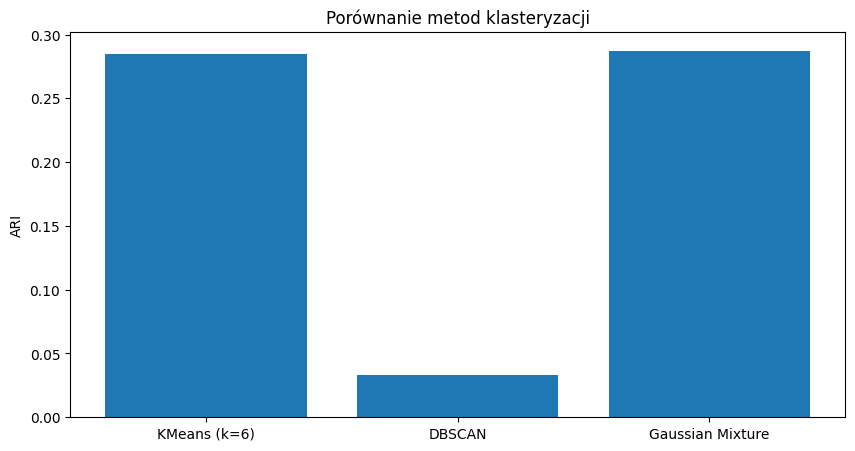

In [24]:
import matplotlib.pyplot as plt  # biblioteka do tworzenia wykresów

# utworzenie figury
plt.figure(figsize=(10, 5))

# wykres słupkowy
plt.bar(
    comparison["Model"],
    comparison["ARI"]
)

# opis osi Y
plt.ylabel("ARI")

# tytuł wykresu
plt.title("Porównanie metod klasteryzacji")

# wyświetlenie wykresu
plt.show()



# WNIOSKI

Porównanie metod klasteryzacji na zbiorze Samsung HAR

-Przygotowanie danych

Do analizy wykorzystano zbiór Samsung Human Activity Recognition (HAR), zawierający dane z akcelerometru i żyroskopu telefonu komórkowego. Zbiór zawiera 561 cech opisujących ruch użytkownika oraz sześć aktywności:

Walking,
Walking Upstairs,
Walking Downstairs,
Sitting ,
Standing ,
Laying .

Ponieważ zadanie dotyczyło metod Unsupervised Learning, etykiety aktywności nie były wykorzystywane podczas trenowania modeli. Zostały użyte jedynie na etapie oceny jakości klasteryzacji.

Zbiory treningowy i testowy zostały połączone, ponieważ w klasteryzacji nie ma potrzeby klasycznego podziału na dane treningowe i testowe. Celem było znalezienie naturalnej struktury danych w całym zbiorze.

Przed trenowaniem modeli dane zostały przeskalowane przy użyciu StandardScaler.

Dobór liczby klastrów dla KMeans:

 - Do określenia liczby klastrów wykorzystano metodę Elbow Method oraz Silhouette Score.

Elbow Method:

- Na wykresie Elbow Method punkt przegięcia znajdował się w okolicach k=6, co jest zgodne z liczbą aktywności występujących w zbiorze danych.

Silhouette Score

Najwyższy wynik Silhouette Score uzyskano dla:

-k = 2
-Silhouette Score = 0.394

Oznacza to, że dane naturalnie grupują się przede wszystkim w dwie główne kategorie:

- aktywności dynamiczne (walking, walking upstairs,walking downstairs),
- aktywności statyczne (sitting, standing, laying).

Pomimo tego do dalszej analizy wykorzystano również model KMeans z k=6, ponieważ odpowiada on liczbie rzeczywistych aktywności występujących w zbiorze.

KMeans

Dla modelu KMeans przyjęto:

- liczba klastrów = 6

Wynik:

 - ARI = 0.285

Analiza tabeli krzyżowej wykazała, że model stosunkowo dobrze oddzielił aktywności ruchowe od statycznych. Nie potrafił jednak jednoznacznie rozróżnić podobnych aktywności w obrębie tych grup.

Aktywności:

Walking,
Walking Upstairs,
Walking Downstairs

często trafiały do tych samych klastrów.

Podobnie:

Sitting,
Standing,
Laying

również były mieszane pomiędzy klastrami.

Oznacza to, że KMeans potrafił rozpoznać ogólny charakter aktywności, jednak miał trudności z dokładnym rozróżnieniem wszystkich sześciu klas.




DBSCAN

Dla algorytmu DBSCAN uzyskano:

 - ARI = 0.034

Analiza wyników pokazała, że około 78% obserwacji zostało oznaczonych jako szum (etykieta -1).

Algorytm utworzył jedynie jeden większy klaster oraz kilka bardzo małych grup zawierających od kilku do kilkudziesięciu obserwacji.
Tak niski wynik jest prawdopodobnie związany z bardzo dużą liczbą cech (561). DBSCAN opiera się na analizie odległości i gęstości punktów. W przestrzeniach o wysokiej wymiarowości odległości pomiędzy obserwacjami stają się mniej informatywne, co znacząco utrudnia poprawne wykrywanie skupisk danych.

W badanym przypadku DBSCAN okazał się najmniej skuteczną metodą klasteryzacji.



Gaussian Mixture Model (GMM)

Przetestowano cztery warianty parametru covariance_type:

Covariance Type	ARI:
- tied	    0.331
- spherical	0.292
- full	    0.287
- diag	    0.250

Najlepszy wynik uzyskano dla:

 - covariance_type = tied
 - ARI = 0.331

Wariant tied zakłada wspólną macierz kowariancji dla wszystkich klastrów. Dla analizowanego zbioru danych okazało się to najlepszym założeniem.
Wariant spherical osiągnął wynik bardzo zbliżony do KMeans, co jest zgodne z faktem, że oba podejścia preferują klastry o zbliżonym, kulistym kształcie.

Najsłabszy wynik uzyskano dla wariantu diag, który zakłada brak korelacji pomiędzy cechami. W przypadku danych pochodzących z czujników ruchu takie założenie jest zbyt dużym uproszczeniem.

Porównanie metod.
Metoda	ARI:
- GMM (tied)	0.331
- GMM (spherical)	0.292
- GMM (full)	0.287
- KMeans (k=6)	0.285
- GMM (diag)	0.250
- DBSCAN	0.034

Najlepszy wynik uzyskał Gaussian Mixture Model z parametrem covariance_type="tied".

KMeans osiągnął nieco słabszy wynik, ale również poprawnie rozróżniał aktywności dynamiczne od statycznych.

DBSCAN nie poradził sobie z analizowanym zbiorem danych.

Odpowiedź na pytanie rekrutacyjne:

- KMeans

Algorytm klasteryzacji dzielący dane na k klastrów poprzez iteracyjne wyznaczanie centroidów i przypisywanie do nich obserwacji na podstawie odległości.

- K-Fold

Metoda walidacji modelu. Zbiór danych jest dzielony na k części, a model trenowany i oceniany wielokrotnie na różnych podziałach danych. Nie jest algorytmem uczenia maszynowego.

- K Nearest Neighbors (KNN)

Algorytm klasyfikacji lub regresji. Przewiduje klasę nowej obserwacji na podstawie k najbliższych sąsiadów w zbiorze treningowym.

Pomimo podobnej nazwy, KMeans, K-Fold i KNN rozwiązują zupełnie różne problemy:

- KMeans służy do klasteryzacji,
- K-Fold do walidacji modeli,
- KNN do klasyfikacji lub regresji.

# ZADANIE PCA 

# PCA - analiza wariancji

PCA (Principal Component Analysis) służy do redukcji liczby cech przy zachowaniu jak największej ilości informacji zawartej w danych.

Najpierw sprawdzamy, ile składowych jest potrzebnych do zachowania większości wariancji.

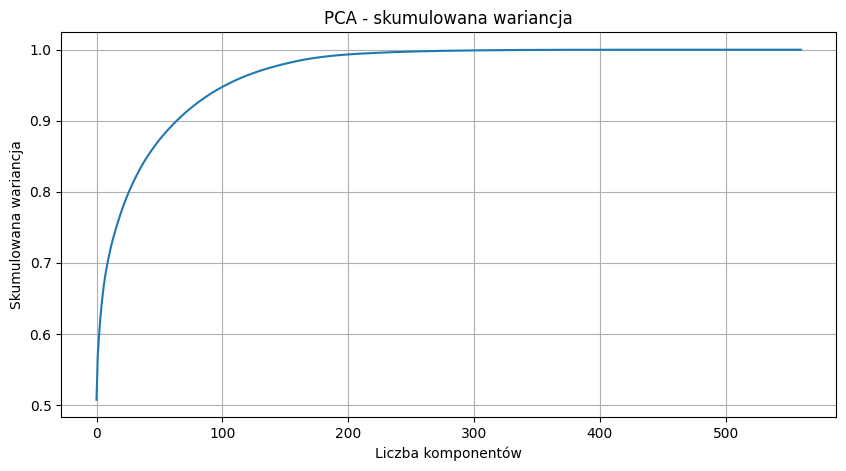

In [25]:
from sklearn.decomposition import PCA  # redukcja wymiarowości
import numpy as np  # obliczenia numeryczne
import matplotlib.pyplot as plt  # wykresy

# PCA bez ograniczenia liczby komponentów
pca = PCA()

# dopasowanie PCA
X_pca_full = pca.fit_transform(X_scaled)

# wykres skumulowanej wariancji
plt.figure(figsize=(10, 5))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    )
)

plt.xlabel("Liczba komponentów")
plt.ylabel("Skumulowana wariancja")
plt.title("PCA - skumulowana wariancja")
plt.grid()

plt.show()

In [26]:
#wybor liczny komponentow

In [27]:
for i, variance in enumerate(
    np.cumsum(pca.explained_variance_ratio_),
    start=1
):
    if variance >= 0.95:

        print(
            "95% wariancji zachowane dla",
            i,
            "komponentów"
        )

        break

95% wariancji zachowane dla 104 komponentów


#pca zastosowanie

In [28]:
from sklearn.decomposition import PCA  # PCA

# zachowanie 95% informacji
pca = PCA(
    n_components=0.95,
    random_state=42
)

# redukcja wymiarowości
X_pca = pca.fit_transform(X_scaled)

print("Przed PCA:", X_scaled.shape)
print("Po PCA:", X_pca.shape)

Przed PCA: (10299, 561)
Po PCA: (10299, 104)


#KMeans po PCA

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# model KMeans
kmeans_pca = KMeans(
    n_clusters=6,
    random_state=42
)

# trening
clusters_kmeans_pca = kmeans_pca.fit_predict(
    X_pca
)

# ARI
ari_kmeans_pca = adjusted_rand_score(
    y.iloc[:, 0],
    clusters_kmeans_pca
)

print(
    "ARI KMeans PCA =",
    ari_kmeans_pca
)

ARI KMeans PCA = 0.29827935605674055


#GMM po PCA

In [30]:
from sklearn.mixture import GaussianMixture

# model GMM
gmm_pca = GaussianMixture(
    n_components=6,
    covariance_type="tied",
    random_state=42
)

# trening
clusters_gmm_pca = gmm_pca.fit_predict(
    X_pca
)

# ARI
ari_gmm_pca = adjusted_rand_score(
    y.iloc[:, 0],
    clusters_gmm_pca
)

print(
    "ARI GMM PCA =",
    ari_gmm_pca
)

ARI GMM PCA = 0.46928488287546677


#BDSCAN po PCA

In [31]:
from sklearn.cluster import DBSCAN

# model DBSCAN
dbscan_pca = DBSCAN(
    eps=2,
    min_samples=10
)

# trening
clusters_dbscan_pca = dbscan_pca.fit_predict(
    X_pca
)

# ARI
ari_dbscan_pca = adjusted_rand_score(
    y.iloc[:, 0],
    clusters_dbscan_pca
)

print(
    "ARI DBSCAN PCA =",
    ari_dbscan_pca
)

ARI DBSCAN PCA = 0.0


In [32]:
comparison_pca = pd.DataFrame({

    "Model": [
        "KMeans",
        "DBSCAN",
        "GMM tied"
    ],

    "ARI bez PCA": [
        0.285064,
        0.033535,
        0.331499
    ],

    "ARI po PCA": [
        ari_kmeans_pca,
        ari_dbscan_pca,
        ari_gmm_pca
    ]

})

comparison_pca

,Model,ARI bez PCA,ARI po PCA
0,KMeans,0.285064,0.298279
1,DBSCAN,0.033535,0.000000
2,GMM tied,0.331499,0.469285


In [33]:
pd.Series(clusters_dbscan_pca).value_counts()

-1    10299
Name: count, dtype: int64

# WNIOSKI

Redukcja wymiarowości przy pomocy PCA wpłynęła w różny sposób na analizowane algorytmy klasteryzacji. Największą poprawę zaobserwowano dla modelu Gaussian Mixture Model z parametrem covariance_type="tied". Wartość ARI wzrosła z 0.331 do 0.469, co oznacza znacznie lepszą zgodność klastrów z rzeczywistymi aktywnościami użytkowników.

W przypadku KMeans poprawa była niewielka. Wartość ARI wzrosła z 0.285 do 0.298, co sugeruje, że redukcja wymiarowości nie miała istotnego wpływu na działanie tego algorytmu.

Najsłabsze wyniki uzyskał DBSCAN. Po zastosowaniu PCA wartość ARI spadła do 0.000. Oznacza to, że przy zastosowanych parametrach algorytm nie był w stanie odnaleźć struktury odpowiadającej rzeczywistym klasom aktywności. Prawdopodobną przyczyną jest konieczność ponownego dostrojenia parametrów eps oraz min_samples po redukcji wymiarowości.

Najlepszą metodą dla badanego zbioru danych okazał się Gaussian Mixture Model połączony z PCA, osiągając najwyższy wynik ARI równy 0.469.
